In [27]:
# Importing pandas as pd and numpy as np

import pandas as pd
import numpy as np

In [28]:
# Loading the dataset into a pandas DataFrame
df = pd.read_csv("heart_disease_data.csv")

In [29]:
# Displaying the first row of the dataset
df.head(1)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0


In [30]:
# Checking the information related to dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [31]:
# Describing the dataset

df.describe

<bound method NDFrame.describe of       male  age  education  currentSmoker  cigsPerDay  BPMeds  \
0        1   39        4.0              0         0.0     0.0   
1        0   46        2.0              0         0.0     0.0   
2        1   48        1.0              1        20.0     0.0   
3        0   61        3.0              1        30.0     0.0   
4        0   46        3.0              1        23.0     0.0   
...    ...  ...        ...            ...         ...     ...   
4233     1   50        1.0              1         1.0     0.0   
4234     1   51        3.0              1        43.0     0.0   
4235     0   48        2.0              1        20.0     NaN   
4236     0   44        1.0              1        15.0     0.0   
4237     0   52        2.0              0         0.0     0.0   

      prevalentStroke  prevalentHyp  diabetes  totChol  sysBP  diaBP    BMI  \
0                   0             0         0    195.0  106.0   70.0  26.97   
1                   0      

In [32]:
# Checking number of rows and columns

df.shape

(4238, 16)

In [33]:
# Counting the value of having chances of CHD 

df["TenYearCHD"].value_counts()

TenYearCHD
0    3594
1     644
Name: count, dtype: int64

In [34]:
# Displaying the last five rows of the dataset
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0


In [35]:
# Step:1 Checking NaN values

df.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [36]:
# We know that if there are NaN values in the dataset that we can drop the 5% of data. 
# But if NaN values are more that 5% of total dataset then we can't drop it.
# The 5% of 4000 is 200 so we can drop BMI,heartRate,totChol,BPMeds,cigsPerDay.

In [37]:
# Let's drop the columns

df = df.dropna(subset=["BMI"])
df = df.dropna(subset=["heartRate"])
df = df.dropna(subset=["totChol"])
df = df.dropna(subset=["BPMeds"])
df = df.dropna(subset=["cigsPerDay"])

In [38]:
# Let's fill the education and glucose NaN rows with the mean values of that particular column

glucose_mean = df["glucose"].mean()
df["glucose"] = df["glucose"].fillna(glucose_mean)
# print(glucose_mean)

education_mean = df["education"].mean()
df["education"] = df["education"].fillna(education_mean)
# print(education_mean)

In [39]:
# Again checking NaN values

df.isna().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [40]:
# Step 2: Encoding of categorical data

# In this dataset there is no categorical data so we do not nedd to perform this step.

In [41]:
# Step 3: Normalization of Numerical data

# There are many columns which needs to do normalization like age,totChol,sysBP,diaBP,BMI,heartRate,glucose,cigsPerDay


In [42]:
# Imprting MinMaxScaler for data preprocessing

from sklearn.preprocessing import MinMaxScaler

In [43]:
# Normalizing the age,totChol,sysBP,diaBP,BMI,heartRate,glucose and cigsPerDay

df["age"] = MinMaxScaler().fit_transform(df[["age"]])
df["totChol"] = MinMaxScaler().fit_transform(df[["totChol"]])
df["sysBP"] = MinMaxScaler().fit_transform(df[["sysBP"]])
df["diaBP"] = MinMaxScaler().fit_transform(df[["diaBP"]])
df["BMI"] = MinMaxScaler().fit_transform(df[["BMI"]])
df["heartRate"] = MinMaxScaler().fit_transform(df[["heartRate"]])
df["glucose"] = MinMaxScaler().fit_transform(df[["glucose"]])
df["cigsPerDay"] = MinMaxScaler().fit_transform(df[["cigsPerDay"]])

In [44]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,0.184211,4.0,0,0.000000,0.0,0,0,0,0.140652,0.106383,0.232804,0.277024,0.363636,0.104520,0
1,0,0.368421,2.0,0,0.000000,0.0,0,0,0,0.234991,0.177305,0.349206,0.319680,0.515152,0.101695,0
2,1,0.421053,1.0,1,0.285714,0.0,0,0,0,0.226415,0.208038,0.338624,0.237518,0.313131,0.084746,0
3,0,0.763158,3.0,1,0.428571,0.0,0,1,0,0.192110,0.314421,0.497354,0.316045,0.212121,0.177966,1
4,0,0.368421,3.0,1,0.328571,0.0,0,0,0,0.295026,0.219858,0.380952,0.183228,0.414141,0.127119,0


In [45]:
# We will separate the Feature Varible and Target Variable

features = ["male", "age", "currentSmoker", "cigsPerDay", "BPMeds", "prevalentStroke", "prevalentHyp", "diabetes", "totChol", "sysBP", "diaBP", "BMI", "heartRate", "glucose"]
X = df[features].values
Y = df["TenYearCHD"].values

In [46]:
# Displaying features columns 

df[features]

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,0.184211,0,0.000000,0.0,0,0,0,0.140652,0.106383,0.232804,0.277024,0.363636,0.104520
1,0,0.368421,0,0.000000,0.0,0,0,0,0.234991,0.177305,0.349206,0.319680,0.515152,0.101695
2,1,0.421053,1,0.285714,0.0,0,0,0,0.226415,0.208038,0.338624,0.237518,0.313131,0.084746
3,0,0.763158,1,0.428571,0.0,0,1,0,0.192110,0.314421,0.497354,0.316045,0.212121,0.177966
4,0,0.368421,1,0.328571,0.0,0,0,0,0.295026,0.219858,0.380952,0.183228,0.414141,0.127119
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4232,1,0.947368,0,0.000000,0.0,0,1,0,0.108062,0.399527,0.518519,0.184198,0.161616,0.110169
4233,1,0.473684,1,0.014286,0.0,0,1,0,0.343053,0.451537,0.465608,0.252787,0.222222,0.129944
4234,1,0.500000,1,0.614286,0.0,0,0,0,0.161235,0.203310,0.338624,0.101066,0.212121,0.079096
4236,0,0.315789,1,0.214286,0.0,0,0,0,0.166381,0.203310,0.412698,0.087736,0.424242,0.118314


In [47]:
# Get the features variable in numpy array
df[features].values

array([[1.        , 0.18421053, 0.        , ..., 0.27702375, 0.36363636,
        0.10451977],
       [0.        , 0.36842105, 0.        , ..., 0.31968008, 0.51515152,
        0.10169492],
       [1.        , 0.42105263, 1.        , ..., 0.23751818, 0.31313131,
        0.08474576],
       ...,
       [1.        , 0.5       , 1.        , ..., 0.10106641, 0.21212121,
        0.07909605],
       [0.        , 0.31578947, 1.        , ..., 0.08773631, 0.42424242,
        0.11831404],
       [0.        , 0.52631579, 0.        , ..., 0.14372273, 0.36363636,
        0.18926554]], shape=(4088, 14))

In [48]:
# Now, Let's train the model

from sklearn.model_selection import train_test_split

In [49]:
# Split the data in 70% and 30% for training and testing the model
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.03)

In [50]:
# Algorithms abbrevations full form

# LOR: Logistic Regression
# KNN: K-Nearest Neighbour
# DT: Decision Tree
# RF: Random Forest
# GB: Gradient Boosting
# XGB: Extreme Gradient Boosting

In [51]:
# In this we are using the LOR, KNN, DT, RF, GB and XGB alogorithm for taining the model

from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

In [52]:
# Here we are creating a model and training the model

model_LOR = LogisticRegression(max_iter=500).fit(X_train, Y_train) 
model_KNN = KNeighborsClassifier(n_neighbors=12).fit(X_train, Y_train)
model_DT = DecisionTreeClassifier().fit(X_train, Y_train)
model_RF = RandomForestClassifier().fit(X_train, Y_train)
model_GB = GradientBoostingClassifier(n_estimators=100, random_state=42).fit(X_train, Y_train)
model_XGB = xgb.XGBClassifier().fit(X_train, Y_train)

In [53]:
# Predicting the Test set results

Y_pred_LOR = model_LOR.predict(X_test)
Y_pred_KNN = model_KNN.predict(X_test)
Y_pred_DT = model_DT.predict(X_test)
Y_pred_RF = model_RF.predict(X_test)
Y_pred_GB = model_GB.predict(X_test)
Y_pred_XGB = model_XGB.predict(X_test)

In [54]:
# Importing accuracy_score from sklearn.metrics

from sklearn.metrics import accuracy_score

In [55]:
# Calculating the model accuracy
# accuracy_score: It is ratio of number of correct output and total number of output

acc_LOR = accuracy_score(Y_test, Y_pred_LOR)*100
acc_KNN = accuracy_score(Y_test, Y_pred_KNN)*100
acc_DT = accuracy_score(Y_test, Y_pred_DT)*100
acc_RF = accuracy_score(Y_test, Y_pred_RF)*100
acc_GB = accuracy_score(Y_test, Y_pred_GB)*100
acc_XGB = accuracy_score(Y_test, Y_pred_XGB)*100

In [56]:
# Printing the accuracy of all algorithms

print("The accuracy for LOR is: ", acc_LOR)
print("The accuracy for KNN is: ", acc_KNN)
print("The accuracy for Decision Tree is: ", acc_DT)
print("The accuracy for Random Forest is: ", acc_RF)
print("The accuracy for Gradient Boosting is: ", acc_GB)
print("The accuracy for Extreme Gradient Boosting is: ", acc_XGB)

The accuracy for LOR is:  83.73983739837398
The accuracy for KNN is:  83.73983739837398
The accuracy for Decision Tree is:  79.67479674796748
The accuracy for Random Forest is:  83.73983739837398
The accuracy for Gradient Boosting is:  83.73983739837398
The accuracy for Extreme Gradient Boosting is:  82.92682926829268


In [57]:
# Importing precision_score, recall_score and f1_score

from sklearn.metrics import precision_score, recall_score, f1_score

In [58]:
# Calculating the model precision_score, recall_score and f1_score values for LOR

precision_LOR = precision_score(Y_test, Y_pred_LOR)
recall_LOR = recall_score(Y_test, Y_pred_LOR)
f1_LOR = f1_score(Y_test, Y_pred_LOR)

In [59]:
# Printing the precision_score, recall_score and f1_score values for LOR algorithms

print("Precision of LOR:", precision_LOR*100)
print("Recall of LOR:", recall_LOR*100)
print("F1 Score of LOR:", f1_LOR*100)

Precision of LOR: 0.0
Recall of LOR: 0.0
F1 Score of LOR: 0.0


In [60]:
# Calculating the model precision_score, recall_score and f1_score values for KNN

precision_KNN = precision_score(Y_test, Y_pred_KNN, zero_division=1)
recall_KNN = recall_score(Y_test, Y_pred_KNN, zero_division=1)
f1_KNN = f1_score(Y_test, Y_pred_KNN, zero_division=1)


In [61]:
# Printing the precision_score, recall_score and f1_score values for KNN algorithms

print("Precision of KNN:", precision_KNN*100)
print("Recall of KNN:", recall_KNN*100)
print("F1 Score of KNN:", f1_KNN*100)

Precision of KNN: 0.0
Recall of KNN: 0.0
F1 Score of KNN: 0.0


In [62]:
# Calculating the model precision_score, recall_score and f1_score values for DT

precision_DT = precision_score(Y_test, Y_pred_DT)
recall_DT = recall_score(Y_test, Y_pred_DT)
f1_DT = f1_score(Y_test, Y_pred_DT)

In [63]:
# Printing the precision_score, recall_score and f1_score values for DT algorithms

print("Precision of DT:", precision_DT*100)
print("Recall of DT:", recall_DT*100)   
print("F1 Score of DT:", f1_DT*100)

Precision of DT: 31.25
Recall of DT: 26.31578947368421
F1 Score of DT: 28.57142857142857


In [64]:
# Calculating the model precision_score, recall_score and f1_score values for RF

precision_RF = precision_score(Y_test, Y_pred_RF)
recall_RF = recall_score(Y_test, Y_pred_RF)
f1_RF = f1_score(Y_test, Y_pred_RF)

In [65]:
# Printing the precision_score, recall_score and f1_score values for RF algorithms

print("Precision of RF:", precision_RF*100)
print("Recall of RF:", recall_RF*100)
print("F1 Score of RF:", f1_RF*100)

Precision of RF: 33.33333333333333
Recall of RF: 5.263157894736842
F1 Score of RF: 9.090909090909092


In [66]:
# Calculating the model precision_score, recall_score and f1_score values for GB

precision_GB = precision_score(Y_test, Y_pred_GB)
recall_GB = recall_score(Y_test, Y_pred_GB)
f1_GB = f1_score(Y_test, Y_pred_GB)

In [67]:
# Printing the precision_score, recall_score and f1_score values for GB algorithms

print("Precision of GB:", precision_GB*100)
print("Recall of GB:", recall_GB*100)
print("F1 Score of GB:", f1_GB*100)

Precision of GB: 0.0
Recall of GB: 0.0
F1 Score of GB: 0.0


In [68]:
# Calculating the model precision_score, recall_score and f1_score values for XGB

precision_XGB = precision_score(Y_test, Y_pred_XGB)
recall_XGB = recall_score(Y_test, Y_pred_GB)
f1_XGB = f1_score(Y_test, Y_pred_XGB)

In [69]:
# Printing the precision_score, recall_score and f1_score values for XGB algorithms

print("Precision of XGB:", precision_XGB*100)
print("Recall of XGB:", recall_XGB*100)
print("F1 Score of XGB:", f1_XGB*100)

Precision of XGB: 25.0
Recall of XGB: 0.0
F1 Score of XGB: 8.695652173913043


In [70]:
# Extreme Gradient Boosting (XGBoost) is selected due to:
# Highest F1 Score: Balances precision and recall better than other models.
# Good Precision: Accurate when predicting positive cases.
# Robust Performance: Handles complex data well.
# Flexibility: Can be fine-tuned to improve recall and overall performance.
# Handles Imbalance: Effective with techniques to address class imbalance.

In [71]:
# Creating some plots

from matplotlib import pyplot as plt
import seaborn as sns

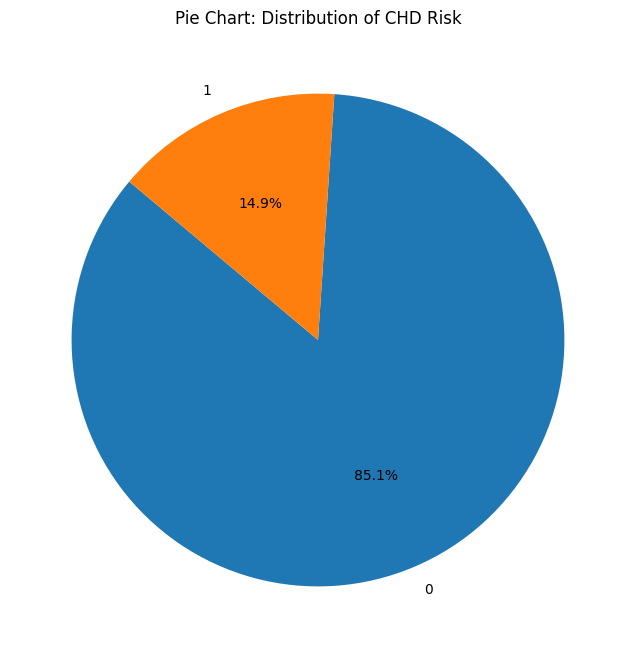

In [72]:

# Pie chart for the distribution of CHD risk

labels = df['TenYearCHD'].value_counts().index
sizes = df['TenYearCHD'].value_counts().values
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart: Distribution of CHD Risk')
plt.show()


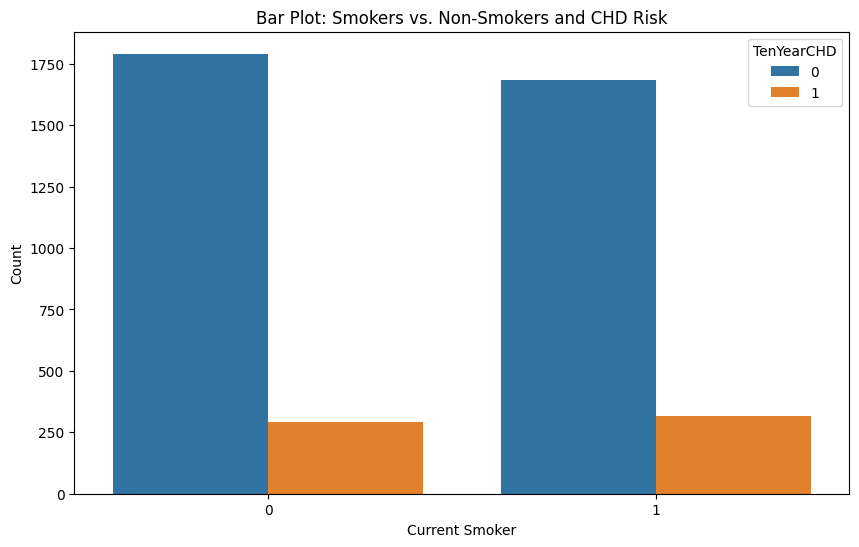

In [73]:
# Bar plot to compare the number of smokers and non-smokers

plt.figure(figsize=(10, 6))
sns.countplot(x='currentSmoker', hue='TenYearCHD', data=df)
plt.title('Bar Plot: Smokers vs. Non-Smokers and CHD Risk')
plt.xlabel('Current Smoker')
plt.ylabel('Count')
plt.show()

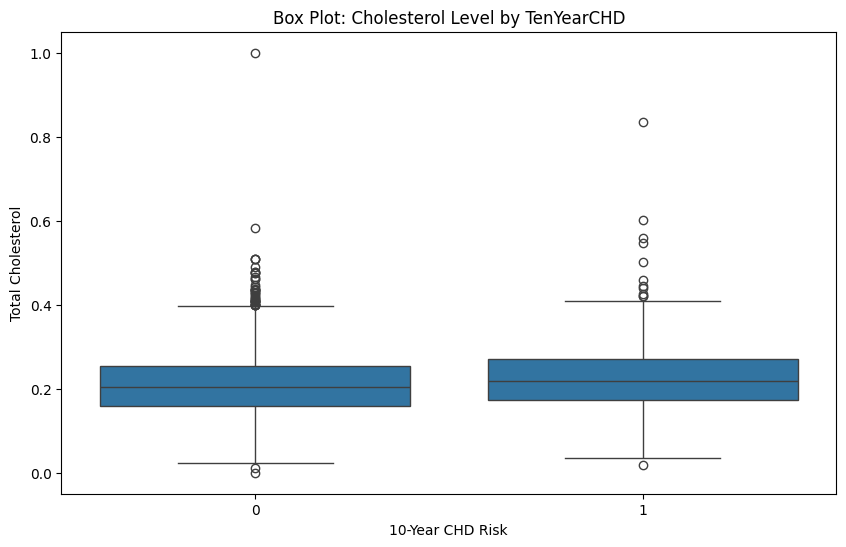

In [74]:
# Box plot to see the distribution of cholesterol levels by TenYearCHD

plt.figure(figsize=(10, 6))
sns.boxplot(x='TenYearCHD', y='totChol', data=df)
plt.title('Box Plot: Cholesterol Level by TenYearCHD')
plt.xlabel('10-Year CHD Risk')
plt.ylabel('Total Cholesterol')
plt.show()

In [75]:
model_XGB

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [76]:
pwd

'C:\\Users\\SUB\\Documents\\Ankit Vishwakarma DA\\Machine Learning\\Machine-Learning-Heart-Disease-Prediction-main'

In [77]:
# Saving the model

import joblib

In [78]:
# Save the model as pickel file

joblib.dump(model_XGB, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [79]:
# load the model from the file

loaded_model = joblib.load("heart_disease_model.pkl")